# Implementação de Árvores de decisão para classificação

## Importações iniciais

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [164]:
from sklearn.preprocessing import RobustScaler
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Implementação bruta utilizando impureza de Gini

In [165]:
class DecisionTree:
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, prediction=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.prediction = prediction

    def __init__(self, max_depth=None, min_samples_split=2, random_state=0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.root = None
        self.n_classes_ = None
        self.n_features_in_ = None

    @staticmethod
    def _gini(y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def _best_split(self, X, y):
        best_gini = self._gini(y)
        best_feature = None
        best_threshold = None
        n_samples, n_features = X.shape

        for feature in range(n_features):
            values = np.unique(X[:, feature])
            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                if not left_mask.any() or not right_mask.any():
                    continue

                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])
                weighted_gini = (
                    left_mask.sum() * left_gini + right_mask.sum() * right_gini
                ) / n_samples

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _grow_tree(self, X, y, depth):
        prediction = self._majority_class(y)
        node = self.Node(prediction=prediction)

        is_pure = len(np.unique(y)) == 1
        reached_depth = self.max_depth is not None and depth >= self.max_depth
        too_few_samples = len(y) < self.min_samples_split
        if is_pure or reached_depth or too_few_samples:
            return node

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return node

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        node.feature = feature
        node.threshold = threshold
        node.left = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        if X.ndim != 2:
            raise ValueError("X deve ser uma matriz bidimensional.")
        if y.ndim != 1 or len(X) != len(y):
            raise ValueError("X e y devem ter o mesmo número de amostras.")
        if self.min_samples_split < 2:
            raise ValueError("min_samples_split deve ser pelo menos 2.")

        self.n_features_in_ = X.shape[1]
        self.n_classes_ = np.unique(y)
        self.root = self._grow_tree(X, y, depth=0)
        return self

    def _predict_one(self, sample, node):
        if node.left is None and node.right is None:
            return node.prediction
        if sample[node.feature] <= node.threshold:
            return self._predict_one(sample, node.left)
        return self._predict_one(sample, node.right)

    def predict(self, X):
        if self.root is None:
            raise ValueError("O modelo precisa ser ajustado com fit antes de predict.")
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X deve ter o mesmo número de atributos usado em fit.")
        return np.array([self._predict_one(sample, self.root) for sample in X])

    def plotree(self, feature_names=None, class_names=None, figsize=(14, 8)):
        if self.root is None:
            raise ValueError("O modelo precisa ser ajustado com fit antes de plotree.")

        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")
        feature_names = feature_names or [f"x{i}" for i in range(self.n_features_in_)]

        def draw(node, x, y, dx, depth):
            if node.left is None and node.right is None:
                label = f"classe = {node.prediction}"
            else:
                label = f"{feature_names[node.feature]} <= {node.threshold:.3f}"

            ax.text(x, y, label, ha="center", va="center", bbox={
                "boxstyle": "round,pad=0.4", "facecolor": "#d9edf7", "edgecolor": "#31708f"
            })
            if node.left is not None:
                left_x, right_x = x - dx, x + dx
                child_y = y - 1.0
                ax.plot([x, left_x], [y - 0.08, child_y + 0.08], color="#777")
                ax.plot([x, right_x], [y - 0.08, child_y + 0.08], color="#777")
                draw(node.left, left_x, child_y, dx / 2, depth + 1)
                draw(node.right, right_x, child_y, dx / 2, depth + 1)

        draw(self.root, 0.5, 0.95, 0.25, 0)
        ax.set_xlim(0, 1)
        ax.set_ylim(-1.0, 1.05)
        plt.show()
        return fig, ax

    plot_tree = plotree

## Divisão do dataset Iris

In [166]:
X, y = load_iris(return_X_y=True,as_frame=True)

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [168]:
rb = RobustScaler()

In [169]:
X_train = rb.fit_transform(X_train)
X_test = rb.transform(X_test)

## Modelagem dataset Iris

In [170]:
dt = DecisionTree()
dtsk = DecisionTreeClassifier(random_state=0)

In [171]:
dt.fit(X_train,y_train)
dtsk.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [172]:
for model in [dt,dtsk]:
    y_pred = model.predict(X_test)
    if(model==dt):
        print("Modelo bruto: ")
    else:
        print("Modelo Scikit-learn: ")
    print(f"Metricas:\nAcurácia:{accuracy_score(y_test,y_pred)}\nPrecisão:{precision_score(y_test,y_pred,average="weighted")}\nRecall:{recall_score(y_test,y_pred,average="weighted")}\nF1-Score:{f1_score(y_test,y_pred,average="weighted")}\n")

Modelo bruto: 
Metricas:
Acurácia:1.0
Precisão:1.0
Recall:1.0
F1-Score:1.0

Modelo Scikit-learn: 
Metricas:
Acurácia:1.0
Precisão:1.0
Recall:1.0
F1-Score:1.0



## Visualização da árvore Iris

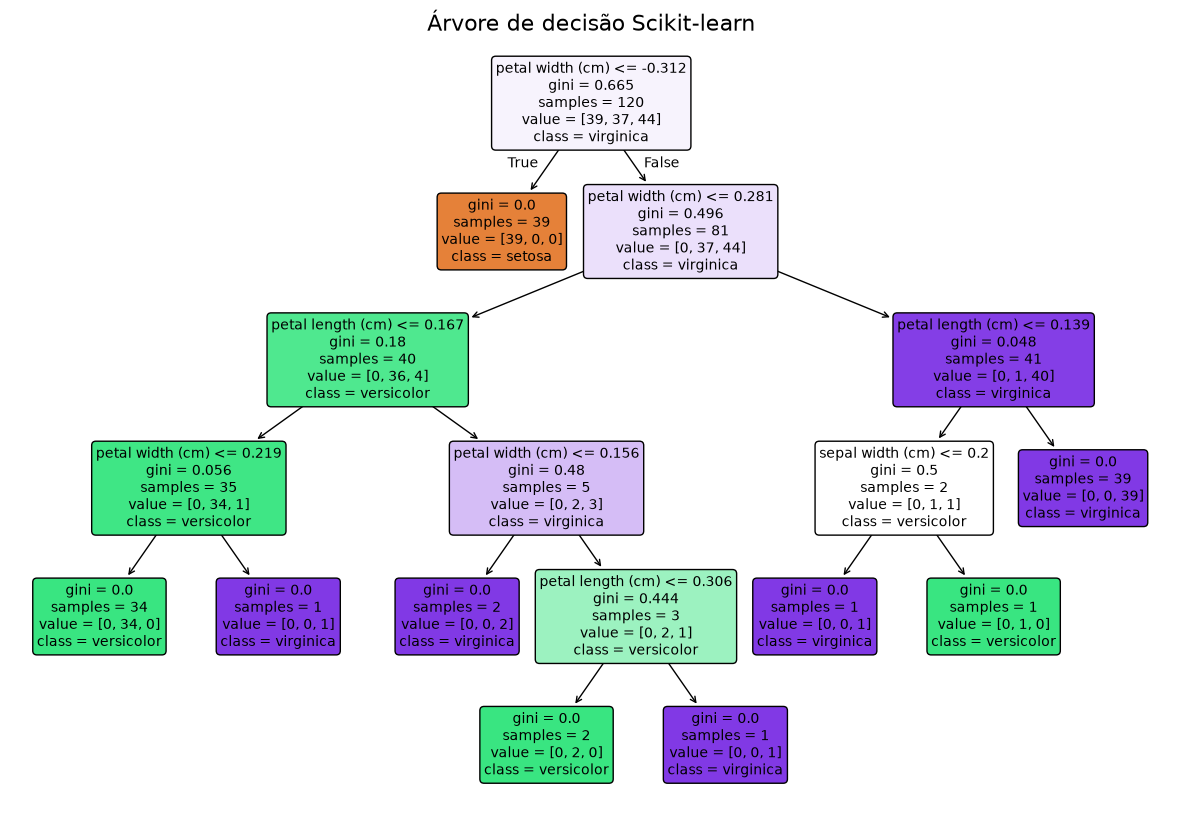

In [173]:
plt.figure(figsize=(15, 10))

plot_tree(
    dtsk, 
    feature_names=X.columns, 
    class_names=['setosa', 'versicolor', 'virginica'],   
    filled=True,                     
    rounded=True,                    
    fontsize=10                      
)

plt.title("Árvore de decisão Scikit-learn", fontsize=16)
plt.show()


## Divisão dataset Breast Cancer

In [174]:
X, y = load_breast_cancer(return_X_y=True,as_frame=True)

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [176]:
rb = RobustScaler()

In [177]:
X_train = rb.fit_transform(X_train)
X_test = rb.transform(X_test)

## Modelagem dataset Breast Cancer

In [178]:
dt = DecisionTree()
dtsk = DecisionTreeClassifier(random_state=0)

In [179]:
dt.fit(X_train,y_train)
dtsk.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [180]:
for model in [dt,dtsk]:
    y_pred = model.predict(X_test)
    if(model==dt):
        print("Modelo bruto: ")
    else:
        print("Modelo Scikit-learn: ")
    print(f"Metricas:\nAcurácia:{accuracy_score(y_test,y_pred)}\nPrecisão:{precision_score(y_test,y_pred,average="weighted")}\nRecall:{recall_score(y_test,y_pred,average="weighted")}\nF1-Score:{f1_score(y_test,y_pred,average="weighted")}\n")

Modelo bruto: 
Metricas:
Acurácia:0.9122807017543859
Precisão:0.9154258194505872
Recall:0.9122807017543859
F1-Score:0.9127213638491835

Modelo Scikit-learn: 
Metricas:
Acurácia:0.9122807017543859
Precisão:0.9154258194505872
Recall:0.9122807017543859
F1-Score:0.9127213638491835



## Visualização da árvore Breast Cancer

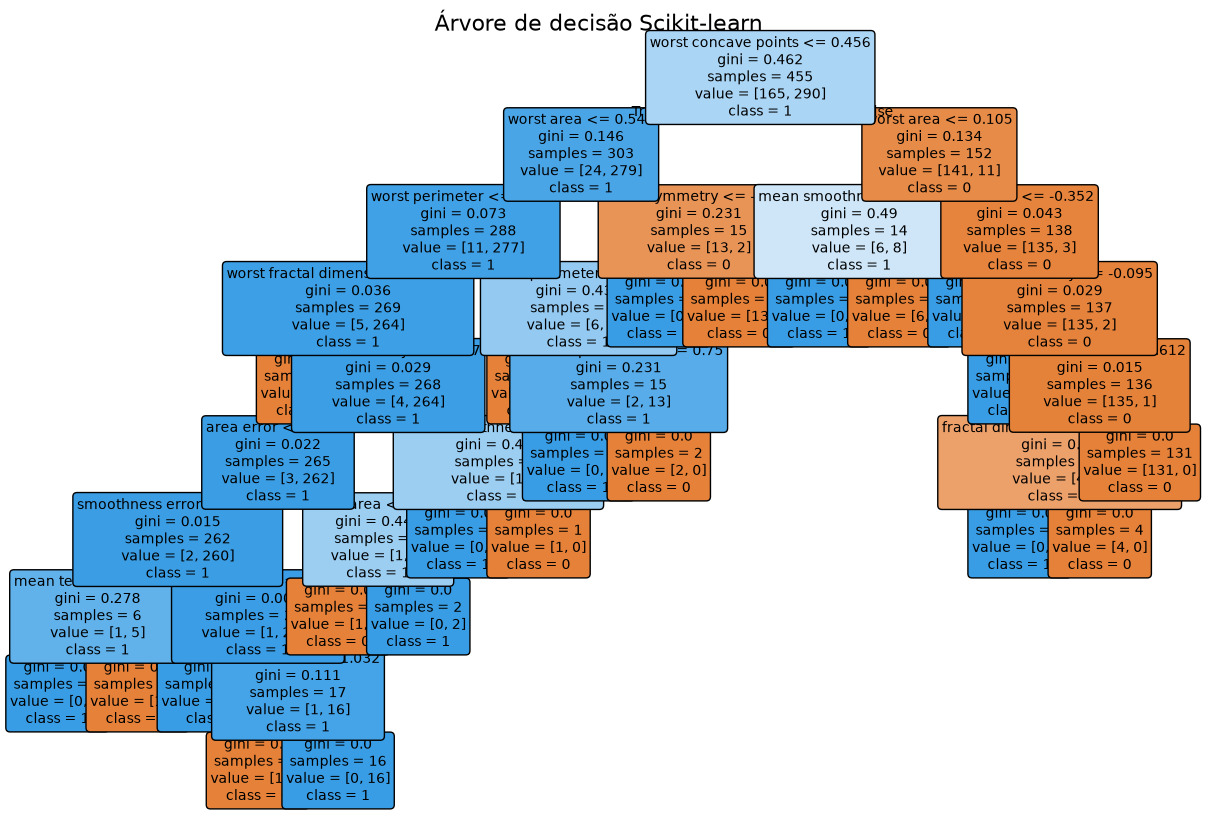

In [181]:
plt.figure(figsize=(15, 10))

plot_tree(
    dtsk, 
    feature_names=X.columns, 
    class_names=["0","1"],   
    filled=True,                     
    rounded=True,                    
    fontsize=10                      
)

plt.title("Árvore de decisão Scikit-learn", fontsize=16)
plt.show()

Como podemos ver, para um dataset mais complexo, como não passamos `max_depth` de parâmetro para os modelos, então a árvore cresceu ao ponto de overfittar no conjunto de treino, ficando extremamente complexa no conjunto de teste.